# Tournament analysis 2 (260715): reward instead of score

Companion to `tournament_analysis_demo`, ranking the shortlisted models on **reward** rather than **player score**.

> **DATA NOTE.** The tournament was run with `build_260724_01_tournament`, which has the no-movement penalty-break absent (verified by decompile + behaviour): every step is penalised, not just non-rest actions. That is a *different* reward structure from what the models were trained under (`build_260715_01_social`, penalty-break **present**, resting free). So the tournament reward does **not** reflect the trained reward landscape.
>
> 
> Hold this notebook back until another tournament is run, using a build with the penalty-break clause in

- **score** = terminal outcome (winner 1.0 High / 0.4 Low, loser 0).
- **reward** (`trialRewards`) = score - step_penalty x (**all** episode steps). Resting is penalised too, and episode length is fixed by the predetermined trial sequence and symmetric between the two competitors, so the penalty is ~constant across models. Reward is therefore essentially **score minus a constant** and reorders nothing; losers get a negative reward.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import analysis.tournament_analysis as ta

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

BASE = os.path.expanduser('~/Unity/Octagon/simulations/tournaments/260715')

# entrants and their strategy band, from the model characterisation notebook. Dict order
# sets the row/column order of every matrix and the legend order, so keep the models
# ordered within a band the way you want them read (here: most extreme first).
STRATEGY = {22: 'central', 20: 'central', 2: 'central',
            14: 'intermediate', 10: 'intermediate',
            36: 'peripheral', 15: 'peripheral', 26: 'peripheral'}
MODELS = ta.models_in_order(STRATEGY)      # grouped by band, in the order above

STEP_PENALTY = 0.001    # for reference; reward = score - STEP_PENALTY * action_steps

## Main pass — load every matchup

In [2]:
# One row per completed trial per matchup: both models, the winning client, each model's
# score and reward, and the wall separation. ~5 s per matchup.
trials_df = ta.load_tournament(BASE)
per_matchup = ta.per_matchup_summary(trials_df)

# One row per (focus model, opponent) per trial, so both seat orders pool. Self-matchups
# are dropped — a model cannot out-rank itself. Every trial appears twice, once framed from
# each model's side, so ALWAYS index this table by `focus`.
selfless = ta.perspective_table(trials_df)

260715_0002__vs__260715_0002 done  

260715_0002__vs__260715_0010 done  

260715_0002__vs__260715_0014 done  

260715_0002__vs__260715_0015 done  

260715_0002__vs__260715_0020 done  

...

260715_0036__vs__260715_0015 done  

260715_0036__vs__260715_0020 done  

260715_0036__vs__260715_0022 done  

260715_0036__vs__260715_0026 done  

260715_0036__vs__260715_0036 done  

matchups loaded: 64 / 64   trials: 22312
trials per matchup: min 342, max 349


## Validation

Same fairness checks as the score notebook (nothing here depends on reward): self-matchups near 0.5, small mirror gaps.

In [3]:
ta.validation_report(trials_df, per_matchup, MODELS);

Self-matchup P1 win rate (should be ~0.5):
 model   n  p1_win_rate
     2 349        0.550
    10 342        0.520
    14 349        0.527
    15 349        0.510
    20 349        0.562
    22 349        0.567
    26 349        0.481
    36 349        0.484
  mean 0.525, worst deviation from 0.5: 0.067

Mirror consistency over 28 pairs — mean gap 0.018, max 0.066
    pair  A_asP1  A_asP2   gap
 22 vs 2   0.605   0.539 0.066
22 vs 26   0.691   0.650 0.040
 2 vs 14   0.579   0.616 0.037
15 vs 26   0.504   0.476 0.029
 2 vs 15   0.756   0.782 0.026

winner-take-all (exactly one agent scores per trial): 1.000 of trials
reward range: [-0.988, 0.949]  (negative = moved and lost)


## Head-to-head reward

Each model's mean **reward** against each opponent, mirror-pooled. Compare to the score matrix in the other notebook — the winner of each cell is the same, but the values now net out movement cost.

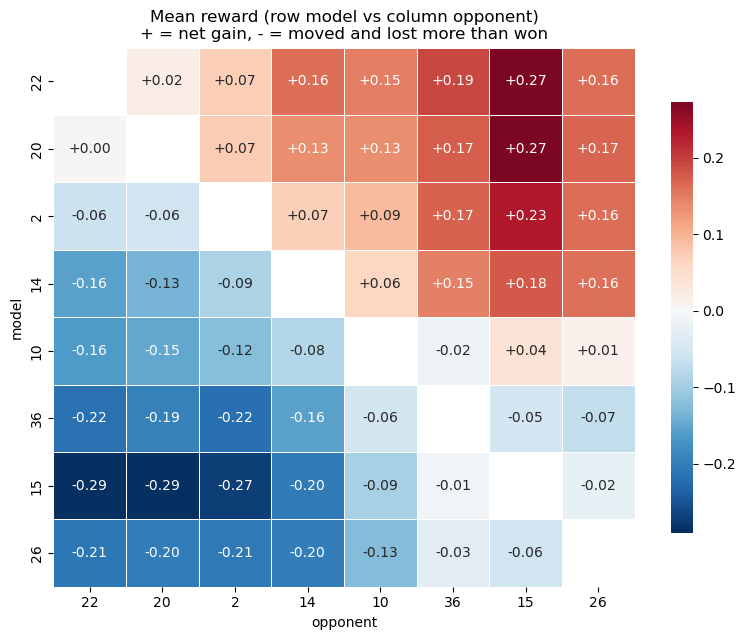

In [4]:
mats = ta.head_to_head(selfless, MODELS)
ta.plot_reward_head_to_head(mats)
plt.show()

## Overall ranking by reward

Each model's mean reward across all opponents (self excluded), with mean score, win rate and Bradley-Terry strength alongside for context. Reward is the net-efficiency headline; the others show how much of it is winning vs cost.

Overall ranking by mean reward:
 rank  model     strategy  mean_reward  mean_score  win_rate  bt_strength
    1     22      central        0.147       0.596     0.653        1.624
    2     20      central        0.138       0.586     0.638        1.532
    3      2      central        0.087       0.537     0.602        1.335
    4     14 intermediate        0.024       0.478     0.519        0.982
    5     10 intermediate       -0.070       0.383     0.453        0.771
    6     36   peripheral       -0.138       0.313     0.391        0.614
    7     26   peripheral       -0.148       0.303     0.400        0.634
    8     15   peripheral       -0.169       0.288     0.342        0.507


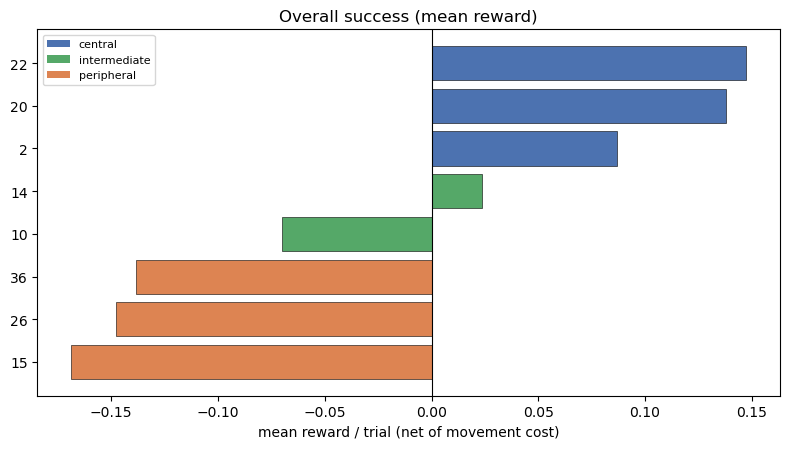

In [5]:
# Same table as the score notebook, ranked on reward instead. Wins (and so the Bradley-Terry
# strengths) are identical either way — reward changes the value of a trial, not its winner.
overall = ta.overall_ranking(selfless, STRATEGY, MODELS, sort_by='mean_reward')
ta.plot_overall_ranking(overall, metric='mean_reward', with_bt=False)
plt.show()

## Score vs reward — does efficiency reorder the models?

The key comparison. Score credits winning; reward credits winning *cheaply*. If peripheral models' lower movement cost matters, they should climb the ranking under reward (and central models, which move most, should drop).

Score vs reward (rank_shift > 0 = model climbs when judged on reward):
 model     strategy  mean_score  mean_reward  score_rank  reward_rank  rank_shift  cost
    22      central       0.596        0.147           1            1           0 0.448
    20      central       0.586        0.138           2            2           0 0.448
     2      central       0.537        0.087           3            3           0 0.450
    14 intermediate       0.478        0.024           4            4           0 0.454
    10 intermediate       0.383       -0.070           5            5           0 0.453
    36   peripheral       0.313       -0.138           6            6           0 0.451
    26   peripheral       0.303       -0.148           7            7           0 0.450
    15   peripheral       0.288       -0.169           8            8           0 0.457


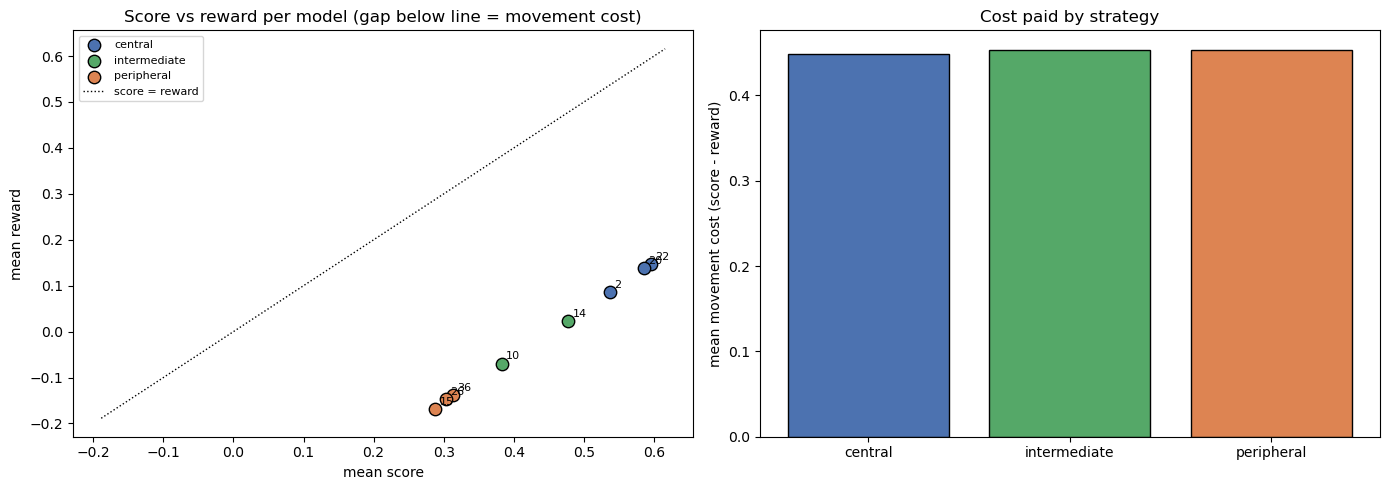

In [6]:
cmp = ta.score_vs_reward(overall)
ta.plot_score_vs_reward(cmp)
plt.show()

## Reading the results

- **Reward ranking = score ranking, exactly** (rank_shift 0 for all 8 models). The per-trial cost (score - reward) is ~0.45 for every model - a constant, because this build penalises every step and episodes are ~fixed length and symmetric between the two competitors.
- So on the tournament data, reward adds nothing over score, and it does **not** measure resting efficiency - this build penalises resting (break absent), the opposite of the training build.
- **To study the reward landscape the models were trained under** (break present, resting free), analyse the **characterisation** data (`model_characterisation_demo`), whose inference used the break-present training build. The tournament, run with a break-absent build, is the wrong tool for that question.
- Wins (who reaches a wall first) are identical to the score notebook, so win-rate and Bradley-Terry are unchanged.